# Model 3 — Disease Prediction

**Dataset:** `cleaned_healthcare_dataset.csv` (500 patient records)

**Target:** `Diagnosis` — a 5-class label: `Healthy`, `Hypertension`, `Coronary Artery Disease`, `Hyperlipidemia`, `Diabetes` (reasonably balanced, 93–104 records per class).

**Note on excluded columns:** `Treatment_Plan` is dropped from the feature set — it is assigned *after* diagnosis and would leak the target. `Patient_ID` and `Follow_Up_Date` are dropped as non-informative identifiers.

Algorithms: **Random Forest, XGBoost**
Evaluation: **Accuracy, Precision, Recall, Confusion Matrix**

*Author: Nusrat — Data Analyst @ Wmolex | Educator, Gurukul Institute of Advanced Technology*


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    confusion_matrix, ConfusionMatrixDisplay, classification_report
)

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (8, 5)
RANDOM_STATE = 42


## 1. Load Data

In [2]:
df = pd.read_csv('cleaned_healthcare_dataset.csv')
print(f"Shape: {df.shape}")
df.head()


Shape: (500, 15)


,Patient_ID,Age,Gender,Blood_Pressure,Heart_Rate,Cholesterol_Level,BMI,Diagnosis,Treatment_Plan,Follow_Up_Date,Is_Outlier,Age_Group,BMI_Category,Cholesterol_Category,BP_Category
0,1,51,Female,97,90,282,35.2,Hypertension,Observation,2024-01-01,False,Middle Age (51-65),Obese,High,Normal
1,2,92,Other,129,80,169,32.3,Healthy,Medication,2024-01-02,False,Senior (66+),Obese,Desirable,Elevated
2,3,14,Male,172,76,157,29.9,Diabetes,Observation,2024-01-03,False,Teen (13-19),Overweight,Desirable,High
3,4,71,Female,131,82,150,19.4,Coronary Artery Disease,Surgery,2024-01-04,False,Senior (66+),Normal,Desirable,Elevated
4,5,60,Male,130,96,206,39.3,Diabetes,Medication,2024-01-05,False,Middle Age (51-65),Obese,Borderline High,Elevated


In [3]:
df.info()
print("\nMissing values:")
print(df.isnull().sum())


<class 'pandas.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 15 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Patient_ID            500 non-null    int64  
 1   Age                   500 non-null    int64  
 2   Gender                500 non-null    str    
 3   Blood_Pressure        500 non-null    int64  
 4   Heart_Rate            500 non-null    int64  
 5   Cholesterol_Level     500 non-null    int64  
 6   BMI                   500 non-null    float64
 7   Diagnosis             500 non-null    str    
 8   Treatment_Plan        500 non-null    str    
 9   Follow_Up_Date        500 non-null    str    
 10  Is_Outlier            500 non-null    bool   
 11  Age_Group             500 non-null    str    
 12  BMI_Category          500 non-null    str    
 13  Cholesterol_Category  500 non-null    str    
 14  BP_Category           500 non-null    str    
dtypes: bool(1), float64(1), int64(5), 

## 2. Target Distribution

Diagnosis
Healthy                    104
Hypertension               101
Coronary Artery Disease    101
Hyperlipidemia             101
Diabetes                    93
Name: count, dtype: int64


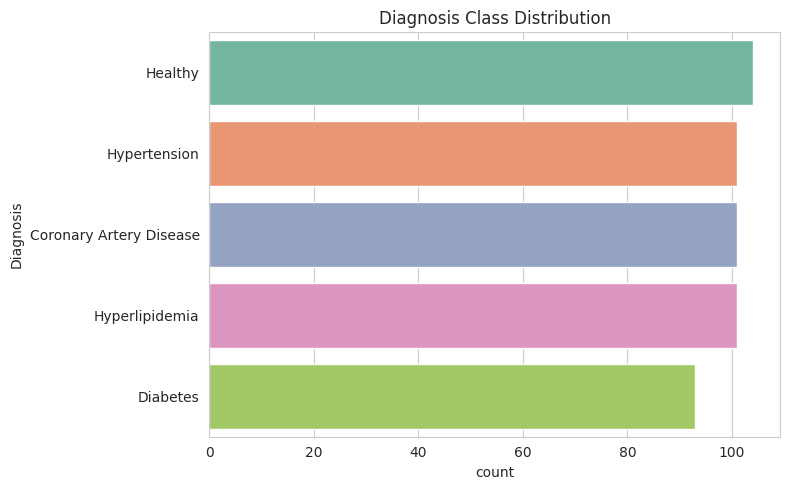

In [4]:
print(df['Diagnosis'].value_counts())

plt.figure(figsize=(8, 5))
sns.countplot(data=df, y='Diagnosis', order=df['Diagnosis'].value_counts().index, palette='Set2')
plt.title('Diagnosis Class Distribution')
plt.tight_layout()
plt.show()


## 3. Feature Preparation

Dropping `Patient_ID`, `Treatment_Plan` (target leakage — assigned post-diagnosis), and `Follow_Up_Date` (non-informative identifier).


In [5]:
df_fe = df.drop(columns=['Patient_ID', 'Treatment_Plan', 'Follow_Up_Date'])
df_fe.head()


,Age,Gender,Blood_Pressure,Heart_Rate,Cholesterol_Level,BMI,Diagnosis,Is_Outlier,Age_Group,BMI_Category,Cholesterol_Category,BP_Category
0,51,Female,97,90,282,35.2,Hypertension,False,Middle Age (51-65),Obese,High,Normal
1,92,Other,129,80,169,32.3,Healthy,False,Senior (66+),Obese,Desirable,Elevated
2,14,Male,172,76,157,29.9,Diabetes,False,Teen (13-19),Overweight,Desirable,High
3,71,Female,131,82,150,19.4,Coronary Artery Disease,False,Senior (66+),Normal,Desirable,Elevated
4,60,Male,130,96,206,39.3,Diabetes,False,Middle Age (51-65),Obese,Borderline High,Elevated


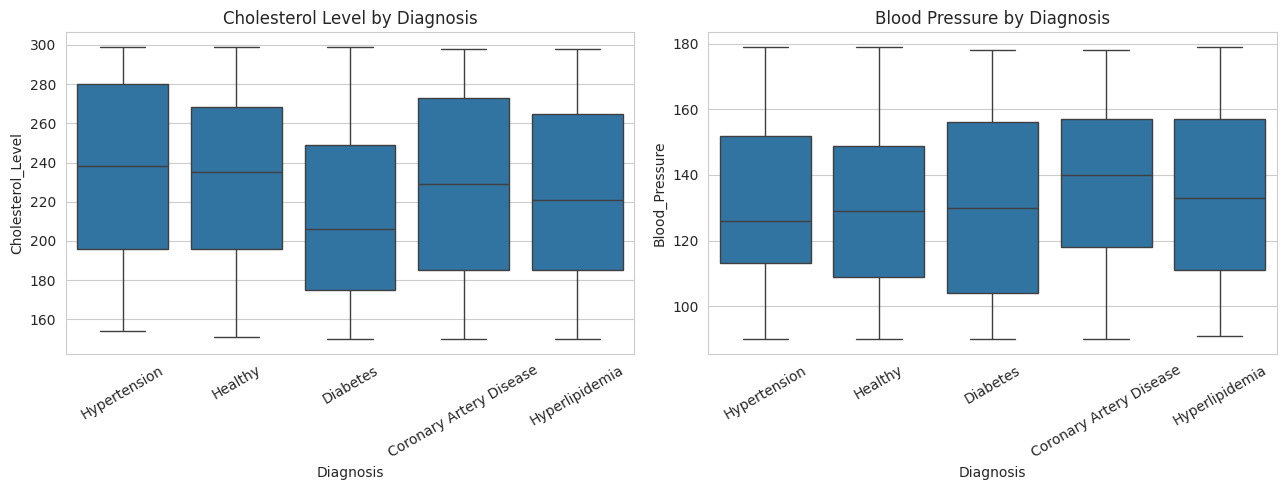

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
sns.boxplot(data=df_fe, x='Diagnosis', y='Cholesterol_Level', ax=axes[0])
axes[0].set_title('Cholesterol Level by Diagnosis')
axes[0].tick_params(axis='x', rotation=30)

sns.boxplot(data=df_fe, x='Diagnosis', y='Blood_Pressure', ax=axes[1])
axes[1].set_title('Blood Pressure by Diagnosis')
axes[1].tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.show()


## 4. Preprocessing Pipeline

In [7]:
target = 'Diagnosis'
X = df_fe.drop(columns=[target])
y_raw = df_fe[target]

label_encoder = LabelEncoder()
y = label_encoder.fit_transform(y_raw)
print("Classes:", list(label_encoder.classes_))

categorical_cols = X.select_dtypes(include=['object', 'bool']).columns.tolist()
numeric_cols = X.select_dtypes(include=[np.number]).columns.tolist()

print("Categorical columns:", categorical_cols)
print("Numeric columns:", numeric_cols)


Classes: ['Coronary Artery Disease', 'Diabetes', 'Healthy', 'Hyperlipidemia', 'Hypertension']
Categorical columns: ['Gender', 'Is_Outlier', 'Age_Group', 'BMI_Category', 'Cholesterol_Category', 'BP_Category']
Numeric columns: ['Age', 'Blood_Pressure', 'Heart_Rate', 'Cholesterol_Level', 'BMI']


In [8]:
preprocessor = ColumnTransformer(transformers=[
    ('num', StandardScaler(), numeric_cols),
    ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), categorical_cols)
])


## 5. Train / Test Split

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)
print(f"Train shape: {X_train.shape}, Test shape: {X_test.shape}")


Train shape: (400, 11), Test shape: (100, 11)


## 6. Train Models — Random Forest & XGBoost

In [10]:
models = {
    'RandomForest': RandomForestClassifier(n_estimators=300, random_state=RANDOM_STATE),
    'XGBoost': XGBClassifier(
        n_estimators=300, max_depth=5, learning_rate=0.05,
        eval_metric='mlogloss', random_state=RANDOM_STATE, use_label_encoder=False
    )
}

fitted_pipelines = {}
pred_results = {}

for name, model in models.items():
    pipe = Pipeline(steps=[('preprocessor', preprocessor), ('classifier', model)])
    pipe.fit(X_train, y_train)
    fitted_pipelines[name] = pipe

    preds = pipe.predict(X_test)
    pred_results[name] = preds
    print(f"{name} trained.")


RandomForest trained.


XGBoost trained.


## 7. Evaluation — Accuracy, Precision, Recall

In [11]:
metrics_rows = []
for name, preds in pred_results.items():
    metrics_rows.append({
        'Model': name,
        'Accuracy': accuracy_score(y_test, preds),
        'Precision (macro)': precision_score(y_test, preds, average='macro'),
        'Recall (macro)': recall_score(y_test, preds, average='macro')
    })

metrics_df = pd.DataFrame(metrics_rows).set_index('Model').sort_values('Accuracy', ascending=False)
metrics_df.round(4)


,Accuracy,Precision (macro),Recall (macro)
Model,,,
RandomForest,0.22,0.2119,0.2178
XGBoost,0.19,0.1919,0.1897


In [12]:
best_model_name = metrics_df.index[0]
best_pipeline = fitted_pipelines[best_model_name]
best_preds = pred_results[best_model_name]

print(f"Best model by Accuracy: {best_model_name}\n")
print(classification_report(y_test, best_preds, target_names=label_encoder.classes_))


Best model by Accuracy: RandomForest

                         precision    recall  f1-score   support

Coronary Artery Disease       0.21      0.20      0.21        20
               Diabetes       0.14      0.16      0.15        19
                Healthy       0.31      0.38      0.34        21
         Hyperlipidemia       0.17      0.10      0.12        20
           Hypertension       0.24      0.25      0.24        20

               accuracy                           0.22       100
              macro avg       0.21      0.22      0.21       100
           weighted avg       0.21      0.22      0.21       100



### Model Comparison — Bar Chart

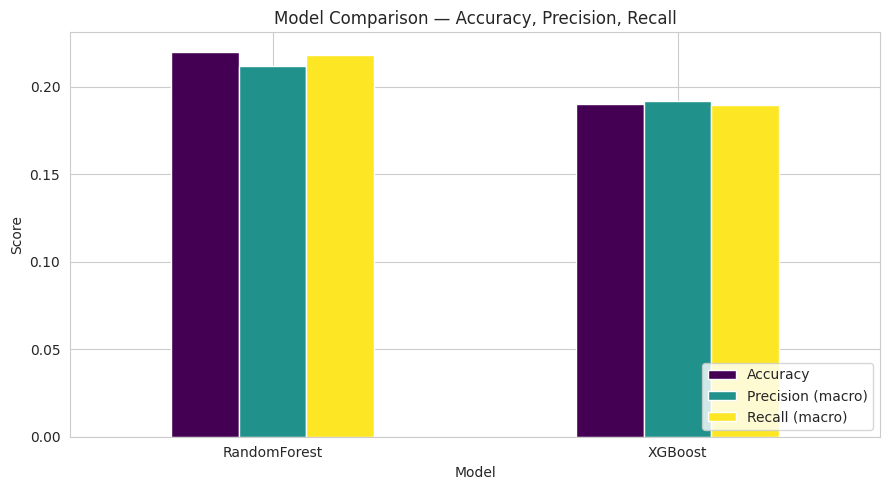

In [13]:
metrics_df.plot(kind='bar', figsize=(9, 5), colormap='viridis')
plt.title('Model Comparison — Accuracy, Precision, Recall')
plt.ylabel('Score')
plt.xticks(rotation=0)
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()


## 8. Confusion Matrix — Both Models

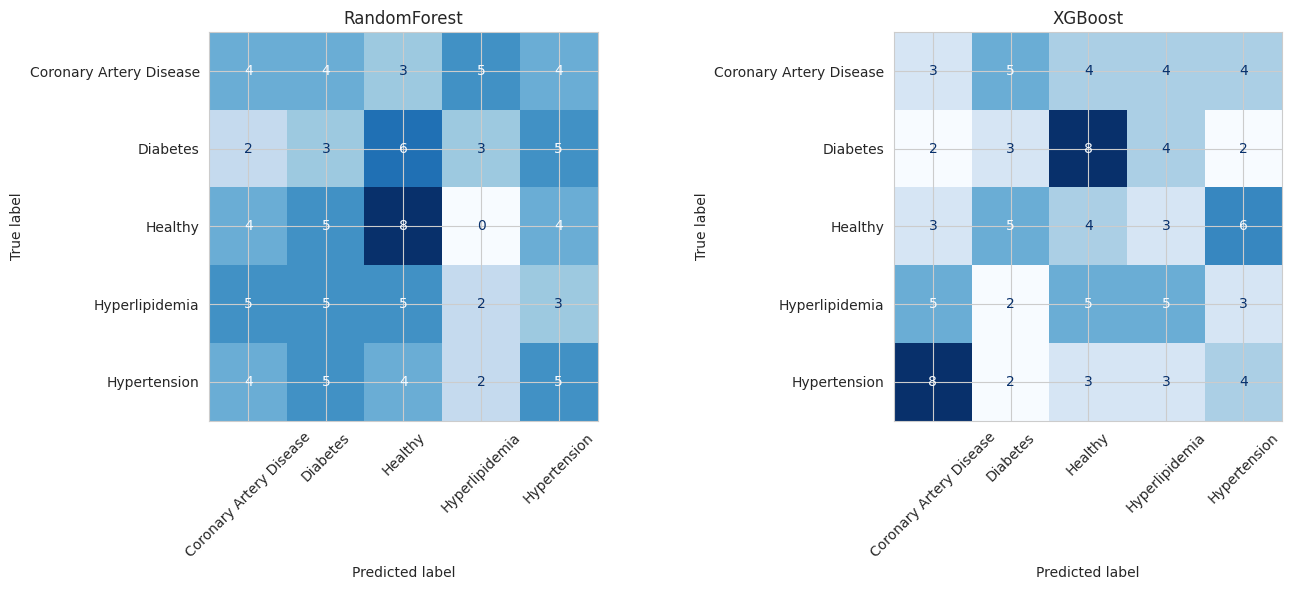

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for ax, (name, preds) in zip(axes, pred_results.items()):
    cm = confusion_matrix(y_test, preds)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=label_encoder.classes_)
    disp.plot(ax=ax, cmap='Blues', colorbar=False, xticks_rotation=45)
    ax.set_title(name)
plt.tight_layout()
plt.show()


## 9. Feature Importance (Best Model)

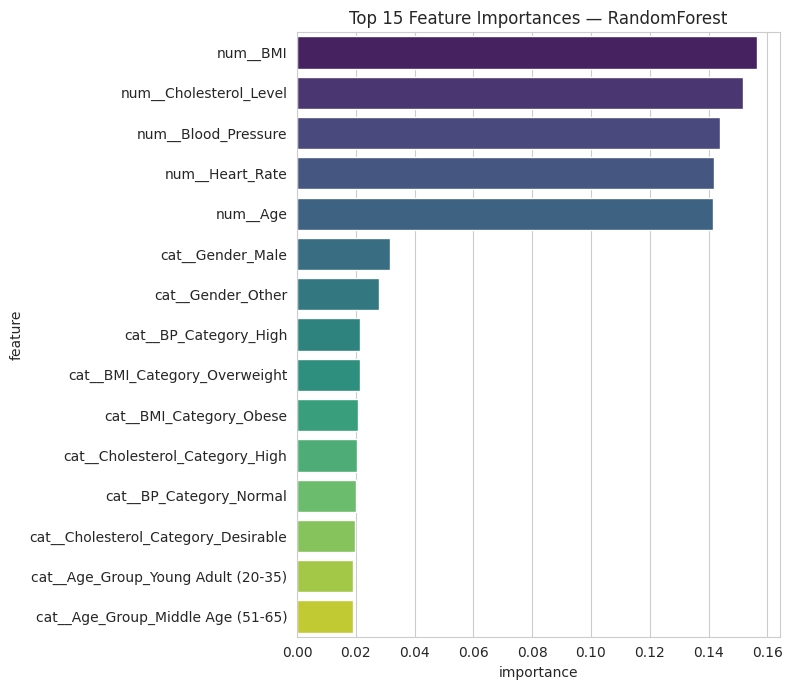

In [15]:
def get_feature_names(pipeline):
    return pipeline.named_steps['preprocessor'].get_feature_names_out()

model_step = best_pipeline.named_steps['classifier']
importances = model_step.feature_importances_
feat_names = get_feature_names(best_pipeline)

fi_df = pd.DataFrame({'feature': feat_names, 'importance': importances})
fi_df = fi_df.sort_values('importance', ascending=False).head(15)

plt.figure(figsize=(8, 7))
sns.barplot(data=fi_df, x='importance', y='feature', palette='viridis')
plt.title(f'Top 15 Feature Importances — {best_model_name}')
plt.tight_layout()
plt.show()


## 10. Summary

- 5-class disease prediction on a reasonably balanced dataset (93–104 records per class out of 500 total) — a small sample, so treat metrics as directional rather than production-grade.
- `Treatment_Plan` was deliberately excluded as a leakage risk since it's assigned based on diagnosis, not before it.
- Random Forest and XGBoost compared on identical preprocessing and the same held-out 20% split, with per-class precision/recall and confusion matrices for both models above.
- With only 500 records for 5 classes (~100 per class, ~80 in training per class), results here should be read as a proof-of-concept baseline — more data would materially firm up these estimates.
